# Mimic IV Dataset – Exploratory Data Analysis (EDA)

Focus:
- Feature distributions
- Missing (null) values



## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

real_path = 'Real_Datasets/MimicIV.csv'
df = pd.read_csv(real_path)

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (24230, 34)


,subject_id,hadm_id,stay_id,gender,age_at_intime,hospital_expire_flag,heart_rate_min,heart_rate_max,heart_rate_mean,sbp_min,...,creatinine_min,creatinine_max,sodium_min,sodium_max,potassium_min,potassium_max,hemoglobin_min,hemoglobin_max,wbc_min,wbc_max
0,10003637,28317408,32824762,M,62,1,72.0,114.0,84.481481,77.0,...,3.0,3.0,132.0,134.0,4.3,5.2,11.5,11.7,13.6,19.9
1,10004235,24181354,34100191,M,47,0,101.0,144.0,115.407407,78.0,...,6.7,8.3,131.0,133.0,3.0,4.3,11.3,12.9,4.9,24.0
2,10004720,22081550,35009126,M,64,1,68.0,86.0,73.955556,86.0,...,0.2,0.3,134.0,136.0,3.7,4.2,10.6,12.4,14.4,16.1
3,10004733,27411876,39635619,M,51,0,82.0,107.0,95.352941,112.0,...,3.3,3.4,144.0,146.0,3.4,3.7,10.0,10.3,7.4,7.4
4,10007818,22987108,32359580,M,69,1,72.0,139.0,93.500000,52.0,...,2.6,4.5,131.0,141.0,3.6,5.1,3.9,9.6,8.4,23.1


## 2. Data Types

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24230 entries, 0 to 24229
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   subject_id            24230 non-null  int64  
 1   hadm_id               24230 non-null  int64  
 2   stay_id               24230 non-null  int64  
 3   gender                24230 non-null  object 
 4   age_at_intime         24230 non-null  int64  
 5   hospital_expire_flag  24230 non-null  int64  
 6   heart_rate_min        24196 non-null  float64
 7   heart_rate_max        24196 non-null  float64
 8   heart_rate_mean       24196 non-null  float64
 9   sbp_min               24190 non-null  float64
 10  sbp_max               24190 non-null  float64
 11  sbp_mean              24190 non-null  float64
 12  dbp_min               24190 non-null  float64
 13  dbp_max               24190 non-null  float64
 14  dbp_mean              24190 non-null  float64
 15  resp_rate_min      

## 3. Missing Values

In [3]:
missing_abs = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    'missing_count': missing_abs,
    'missing_percent': missing_pct
})

total_cells = df.shape[0] * df.shape[1]
total_missing = df.isna().sum().sum()

missing_percentage = (total_missing / total_cells) * 100
print("total missing values:", missing_percentage)

missing_df[missing_df.missing_count > 0].head(20)

total missing values: 0.4141681435264985


,missing_count,missing_percent
temperature_mean,236,0.973999
temperature_max,236,0.973999
temperature_min,236,0.973999
hemoglobin_max,229,0.945109
hemoglobin_min,229,0.945109
wbc_max,227,0.936855
wbc_min,227,0.936855
sodium_max,203,0.837804
sodium_min,203,0.837804
potassium_max,201,0.829550


## 4. Missing Values Plot

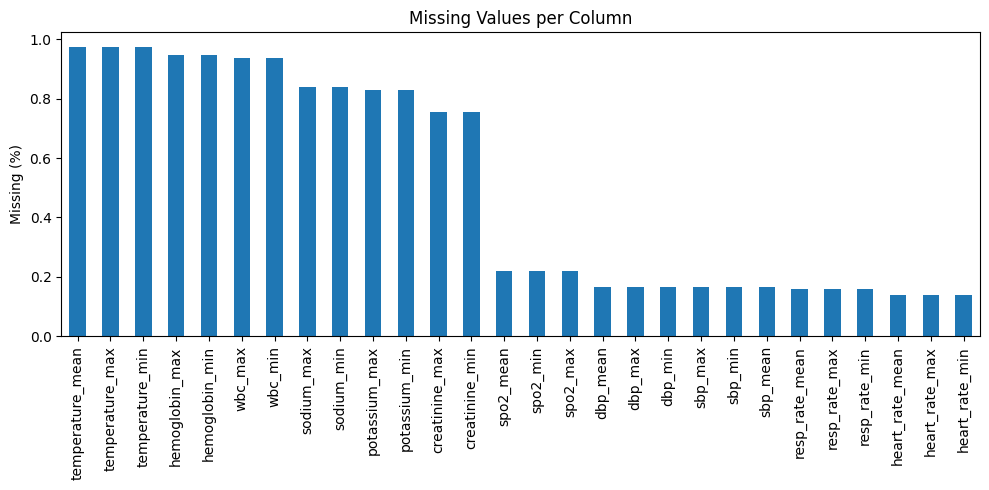

In [4]:
plt.figure(figsize=(10,5))
missing_pct[missing_pct > 0].plot(kind='bar')
plt.ylabel('Missing (%)')
plt.title('Missing Values per Column')
plt.tight_layout()
plt.show()

In [5]:
df_filtered = df[df.notna().sum(axis=1) >= 10]
print("Original shape:", df.shape)
print("Filtered shape:", df_filtered.shape)

print("Rows removed:", df.shape[0] - df_filtered.shape[0])

x = 30  # threshold in percent

missing_pct = df_filtered.isna().mean() * 100
df_filtered2 = df_filtered.loc[:, missing_pct <= x]

removed = set(df_filtered.columns) - set(df_filtered2.columns)
print("Dropped columns:", removed)

print("Filtered2 shape:", df_filtered2.shape)


Original shape: (24230, 34)
Filtered shape: (24230, 34)
Rows removed: 0
Dropped columns: set()
Filtered2 shape: (24230, 34)


## 5. Numeric Distributions

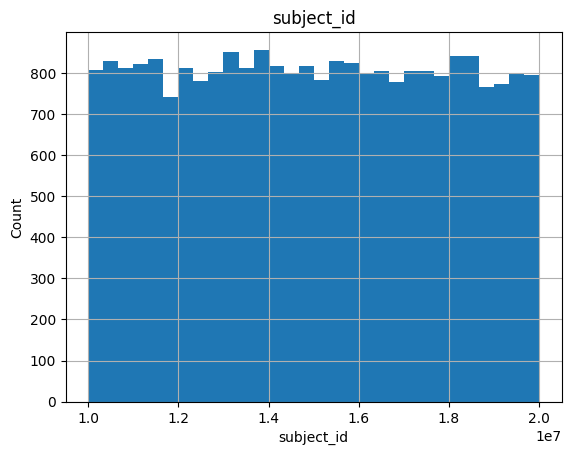

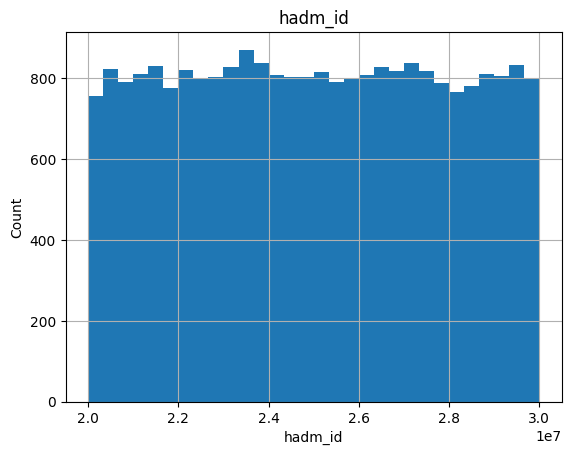

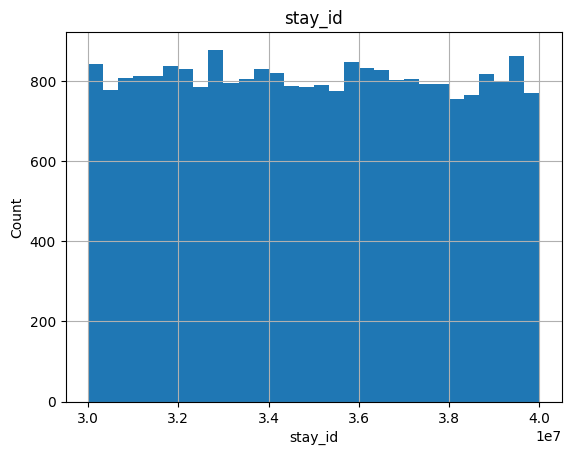

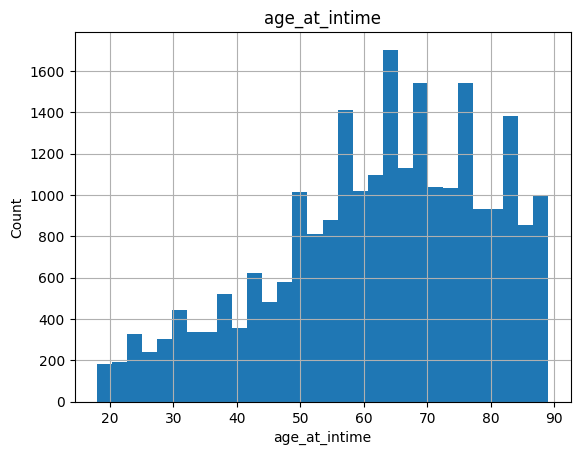

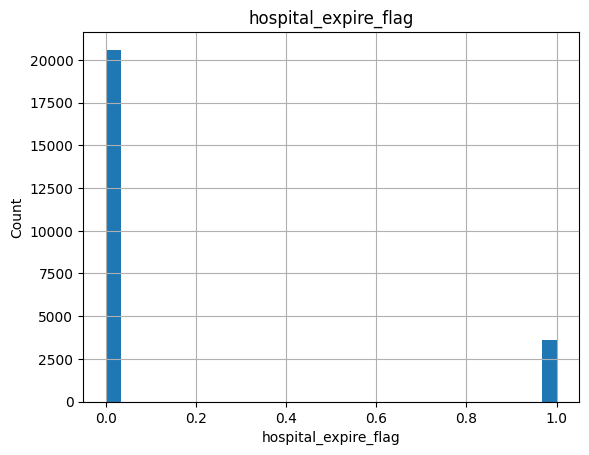

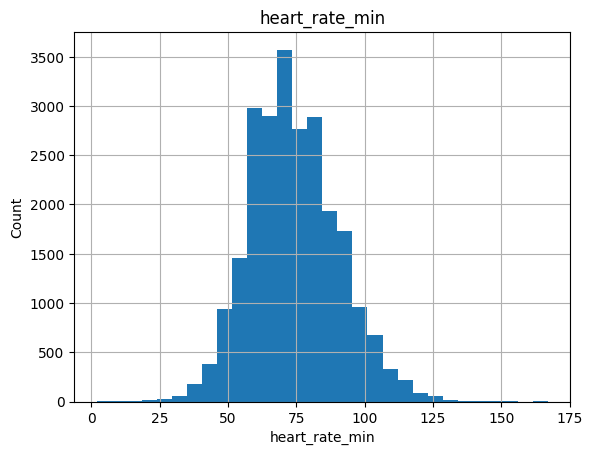

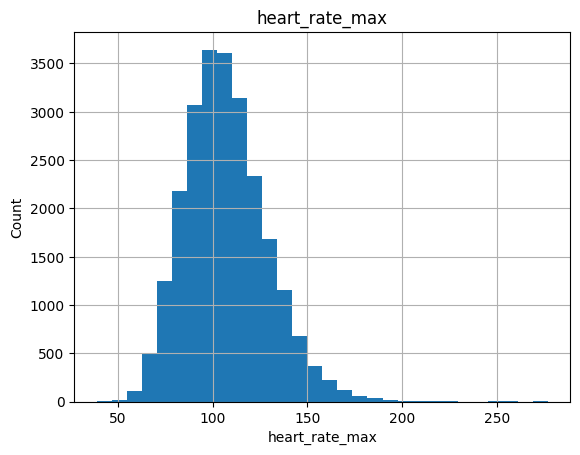

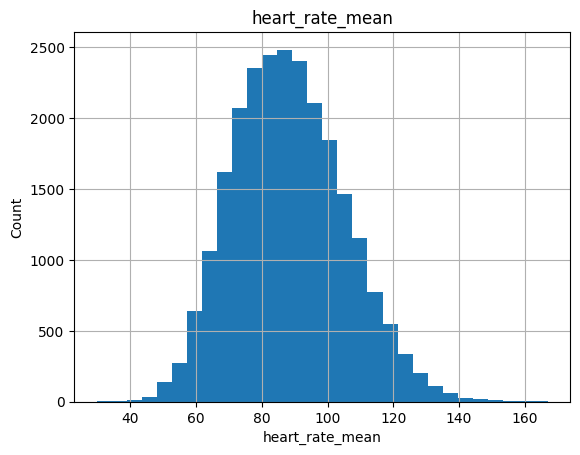

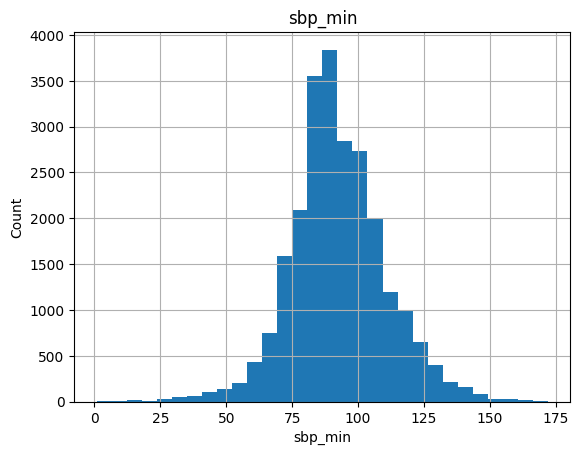

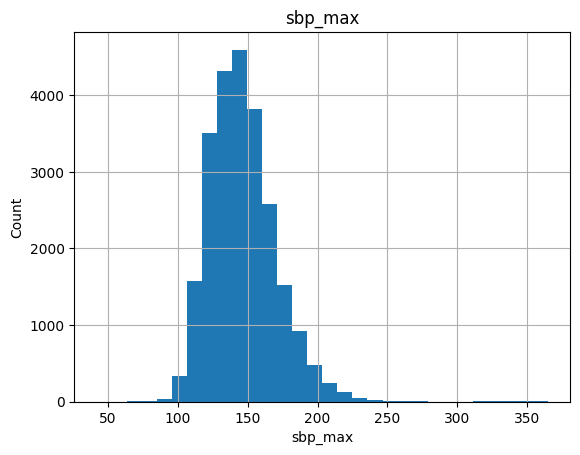

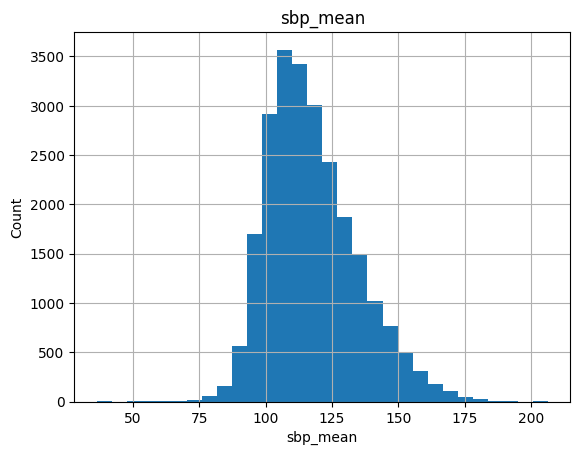

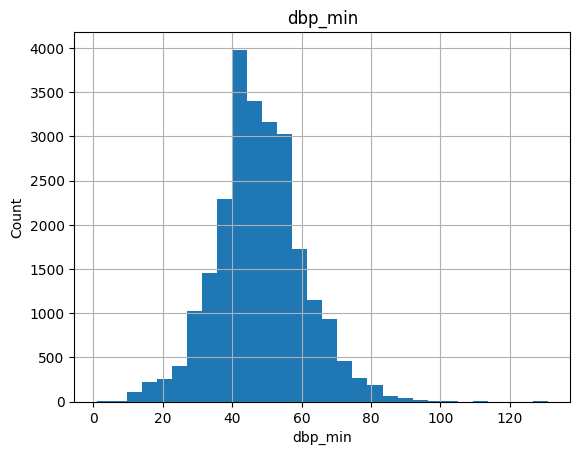

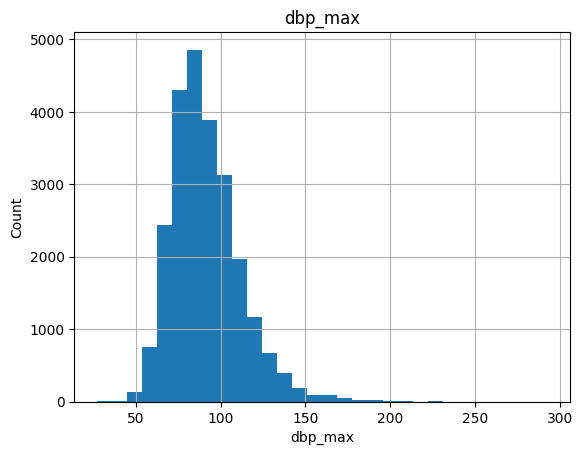

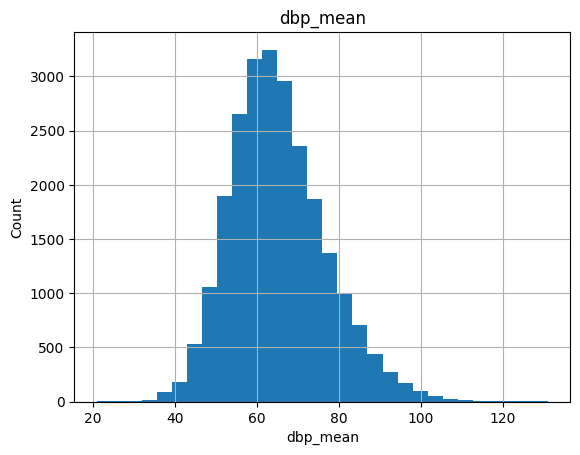

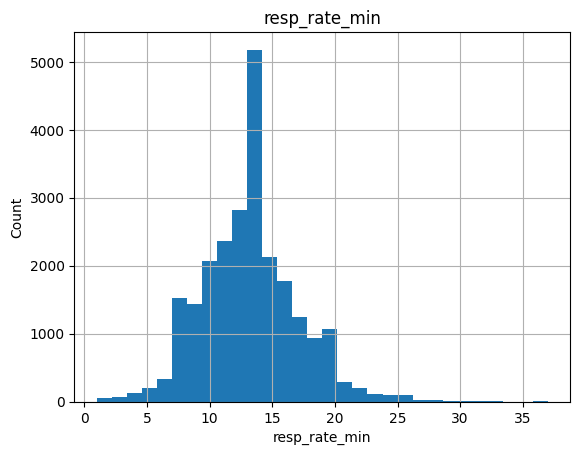

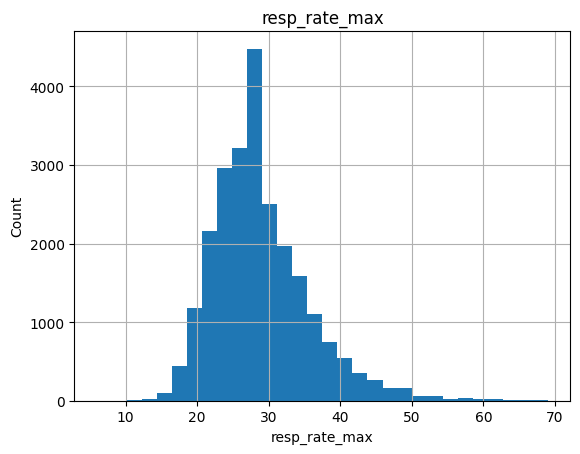

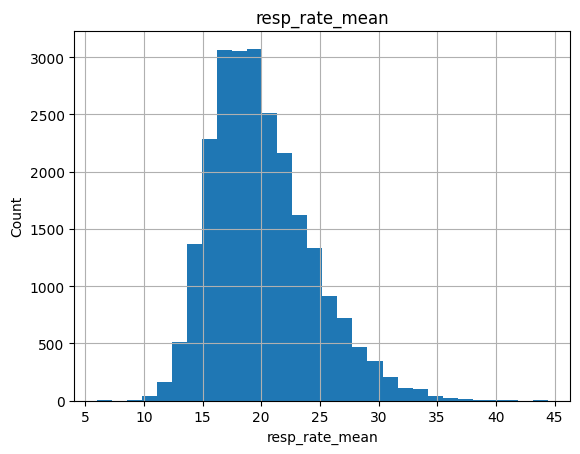

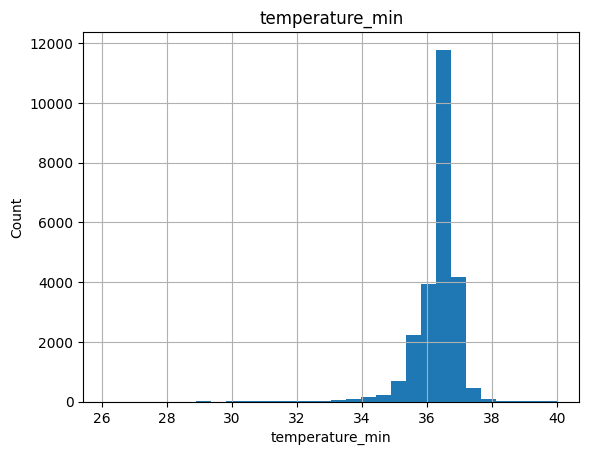

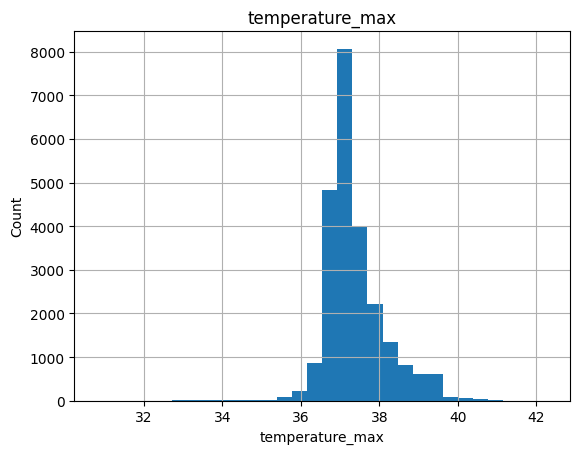

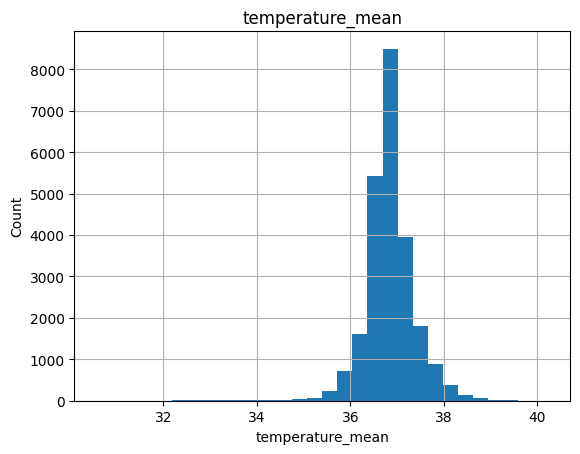

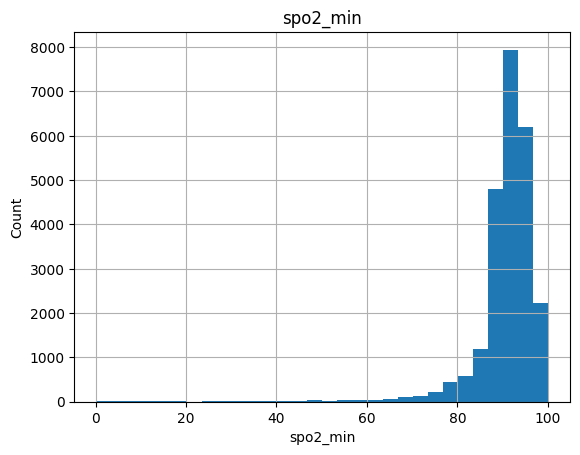

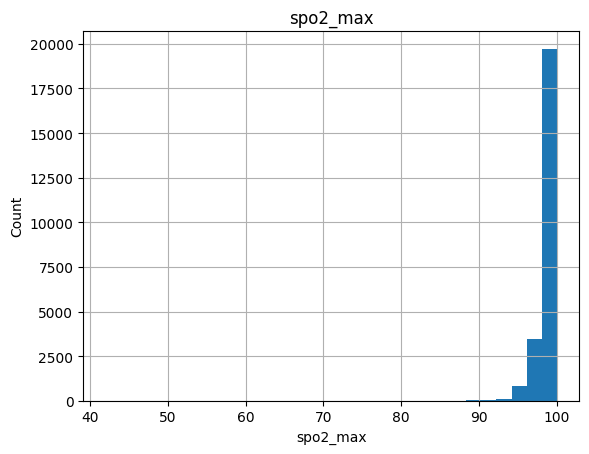

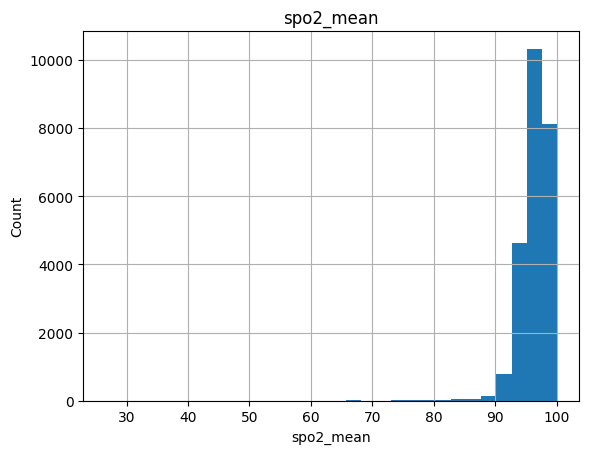

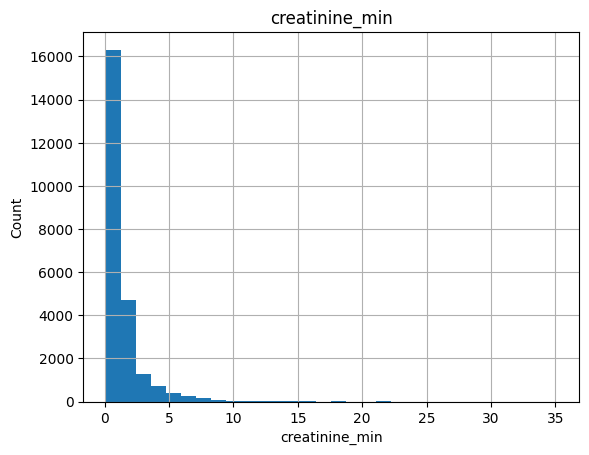

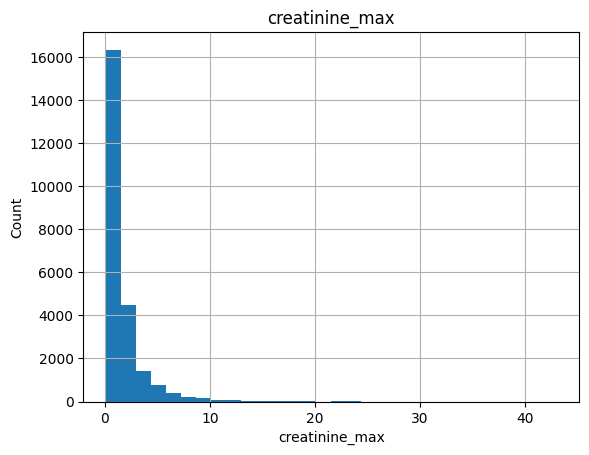

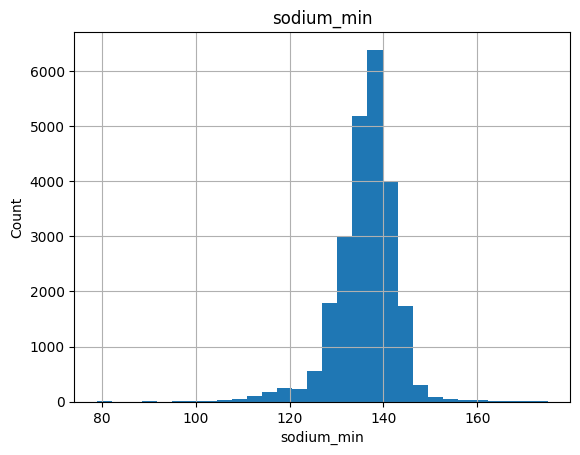

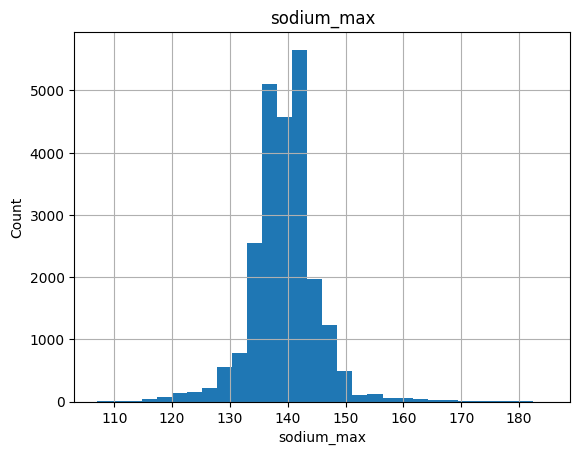

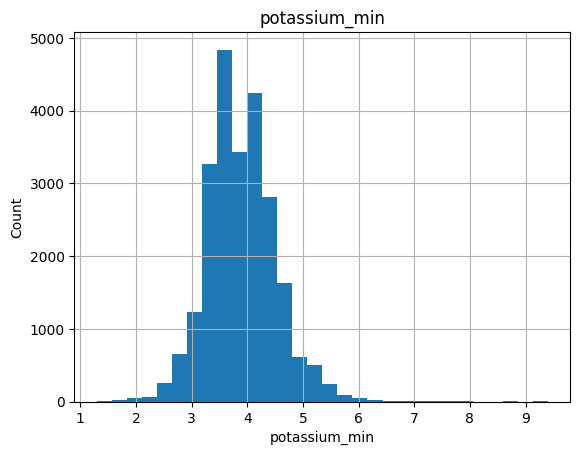

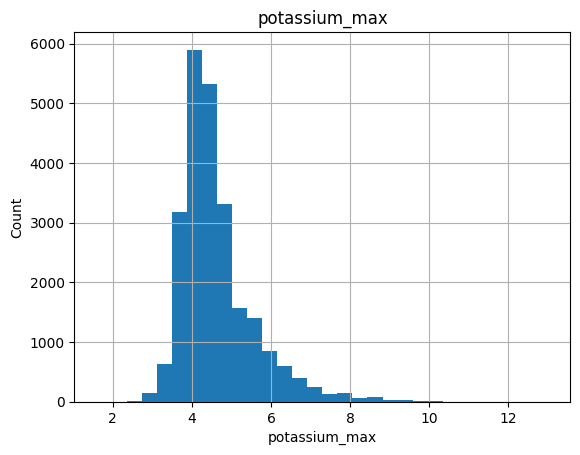

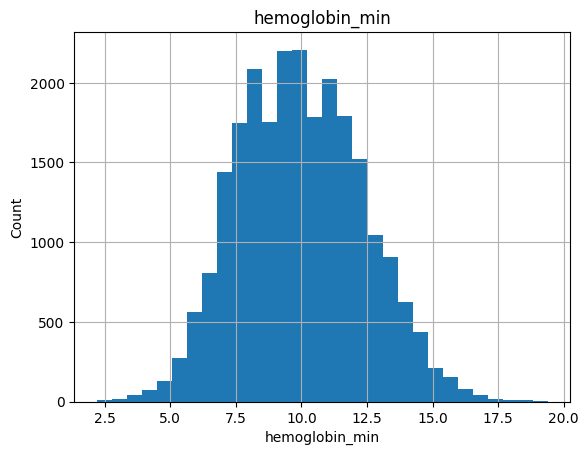

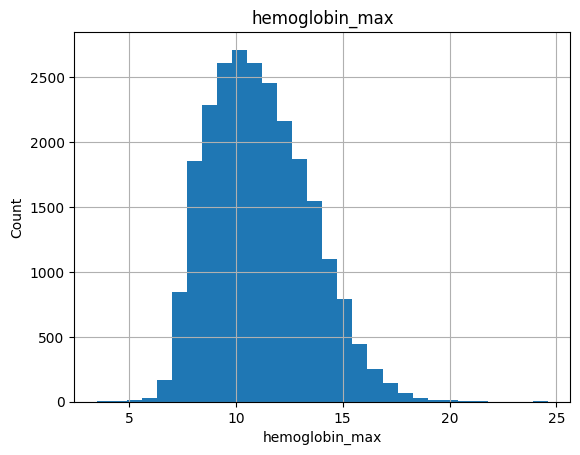

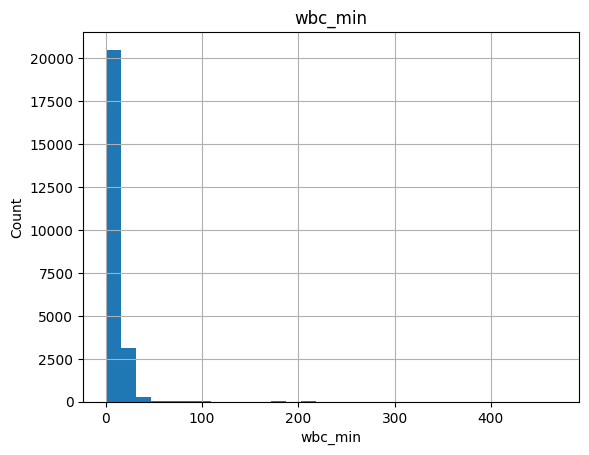

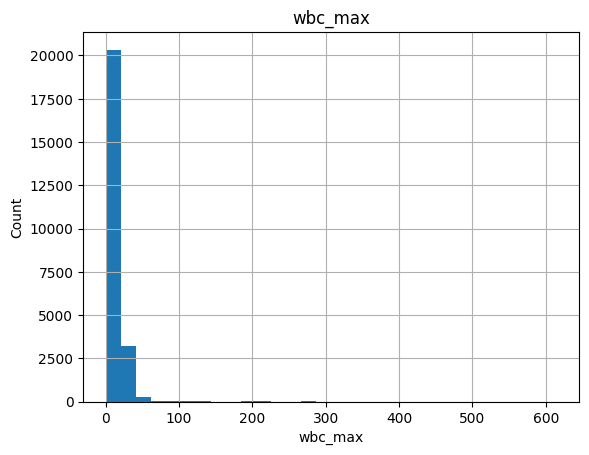

In [6]:
num_cols = df_filtered2.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    plt.figure()
    df_filtered2[col].dropna().hist(bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

## 6. Categorical Distributions

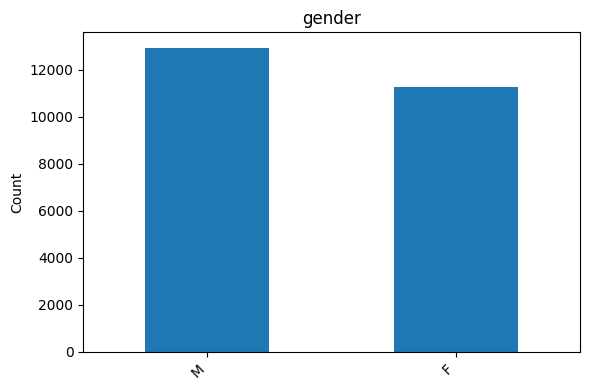

In [7]:
cat_cols = df_filtered2.select_dtypes(exclude=[np.number]).columns.tolist()
for col in cat_cols:
    plt.figure(figsize=(6,4))
    df_filtered2[col].value_counts(dropna=False).head(20).plot(kind='bar')
    plt.title(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 7. Notes
- Columns with high missingness may need imputation or removal
- Highly skewed distributions may require transformation before GAN training